# Proyecto de Regresión Lineal - Coste del Seguro Médico

## Objetivo

En este proyecto construiremos un modelo de regresión lineal capaz de predecir el coste del seguro médico (`charges`) de un cliente a partir de sus características personales.


In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [27]:
# Cargamos el dataset
df = pd.read_csv("../data/raw/medical_insurance_cost.csv")

In [28]:
df.head()



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


##El dataset contiene 1338 registros y 7 columnas.
No existen valores nulos, por lo que inicialmente no será necesario tratar datos faltantes.
Hay 4 variables numéricas (age, bmi, children y charges) y 3 variables categóricas (sex, smoker y region).
La variable objetivo será charges, que representa el coste del seguro médico.
Antes de entrenar el modelo será necesario transformar las variables categóricas en variables numéricas para que la regresión lineal pueda utilizarlas.

In [30]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [31]:
df.duplicated().sum()

np.int64(1)

In [32]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [33]:
df = df.drop_duplicates()

In [34]:
df.duplicated().sum()


np.int64(0)

In [35]:
df.dtypes


age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

El dataset contiene 7 variables. Cuatro son numéricas (age, children, bmi y charges) y tres son categóricas (sex, smoker y region). Las variables categóricas deberán transformarse a formato numérico antes de entrenar un modelo de Machine Learning.

In [36]:
df["sex"].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [37]:
df["smoker"].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [38]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

## Comienza el eda


## Variables categoricas


In [39]:
# Función para analizar variables categóricas
def analizar_categorica(df, columna):

    conteo = df[columna].value_counts()

    print(conteo)

    conteo.plot(kind="bar")

    plt.title(f"Distribución de la variable '{columna}'")
    plt.xlabel(columna)
    plt.ylabel("Número de clientes")

    plt.show()

sex
male      675
female    662
Name: count, dtype: int64


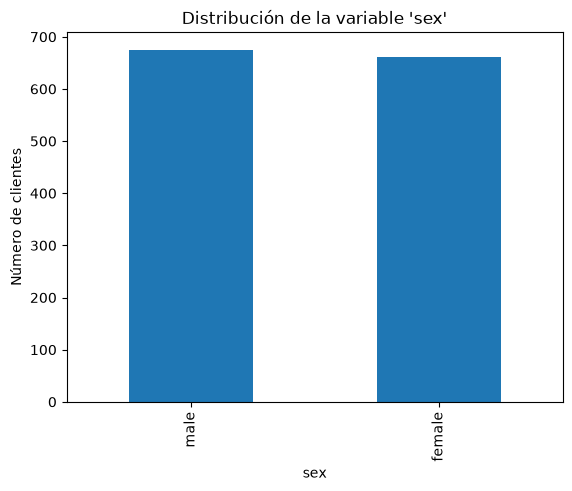

In [40]:
analizar_categorica(df, "sex")

smoker
no     1063
yes     274
Name: count, dtype: int64


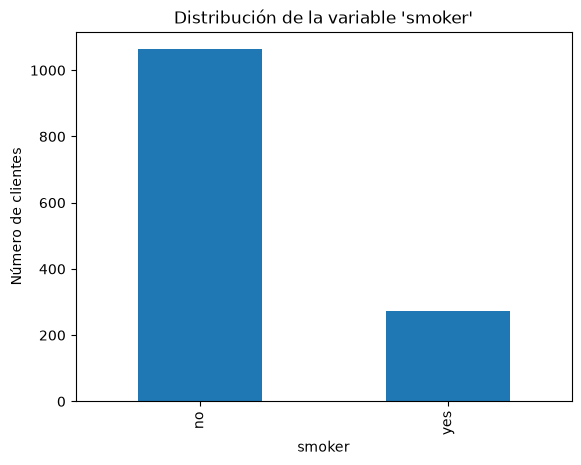

In [41]:
analizar_categorica(df, "smoker")


region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


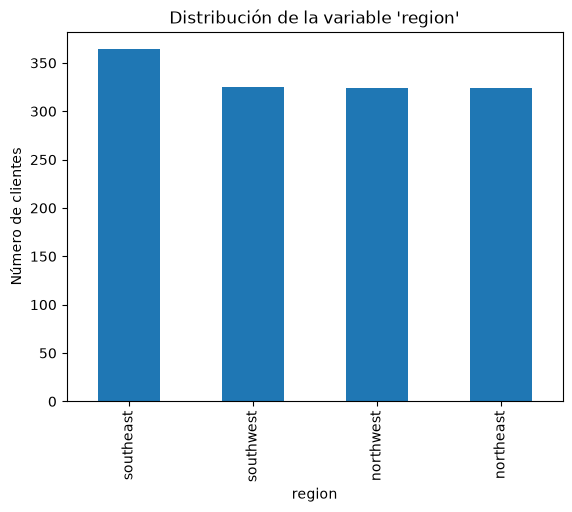

In [42]:
analizar_categorica(df, "region")

## variables numerica

In [43]:
# Función para analizar variables numéricas
def analizar_numerica(df, columna):

    fig, ax = plt.subplots(1, 2, figsize=(14,4))

    # Histograma
    sns.histplot(df[columna], kde=True, ax=ax[0])
    ax[0].set_title(f"Distribución de '{columna}'")

    # Boxplot
    sns.boxplot(x=df[columna], ax=ax[1])
    ax[1].set_title(f"Boxplot de '{columna}'")

    plt.tight_layout()
    plt.show()

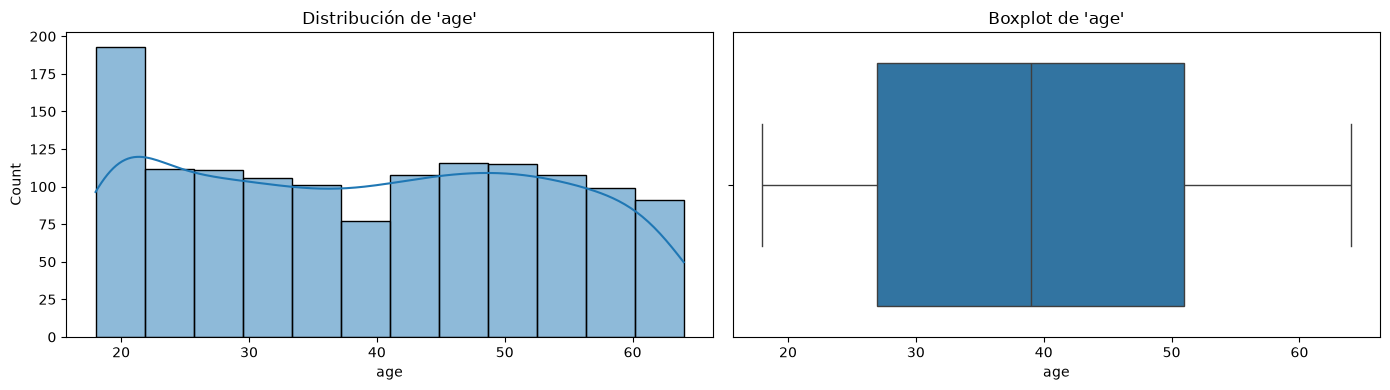

In [44]:
analizar_numerica(df, "age")

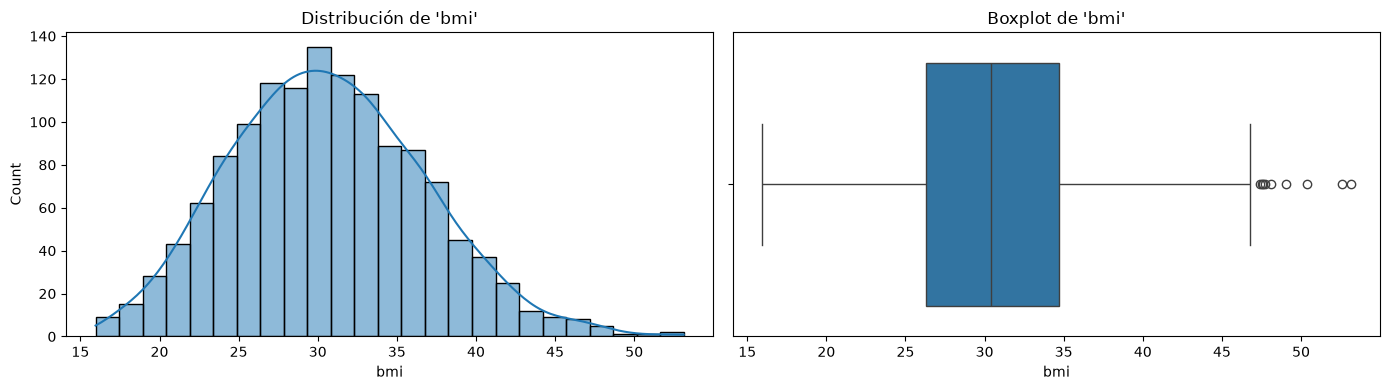

In [45]:
analizar_numerica(df, "bmi")

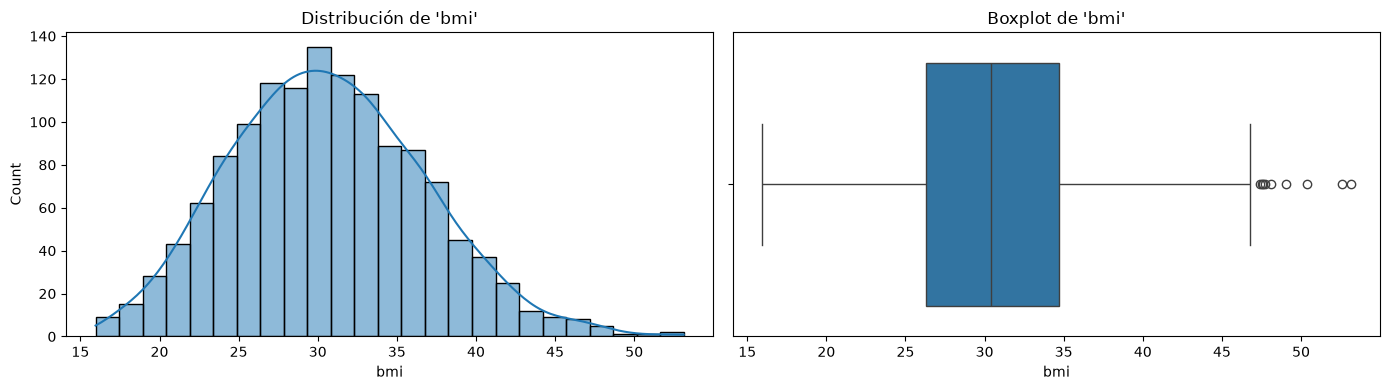

In [46]:
analizar_numerica(df, "bmi")

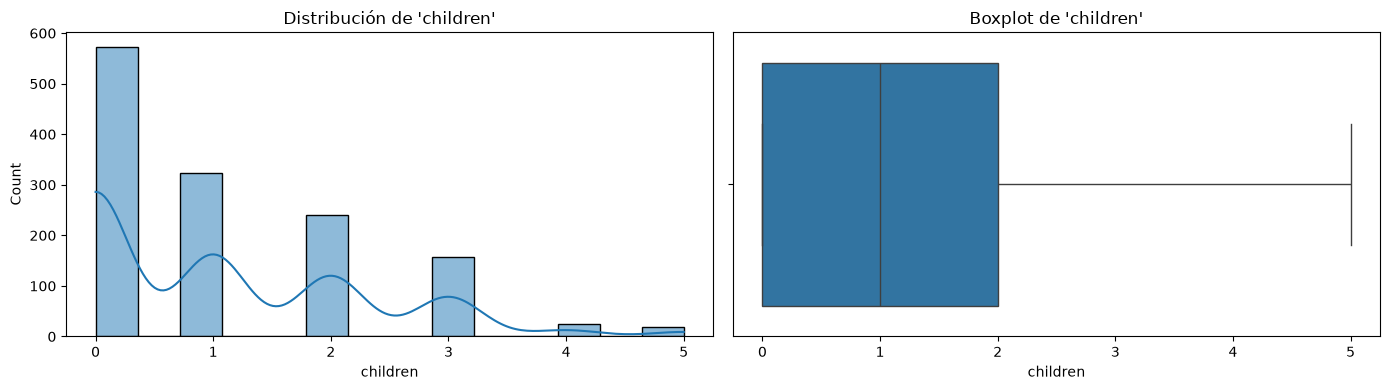

In [47]:
analizar_numerica(df, "children")

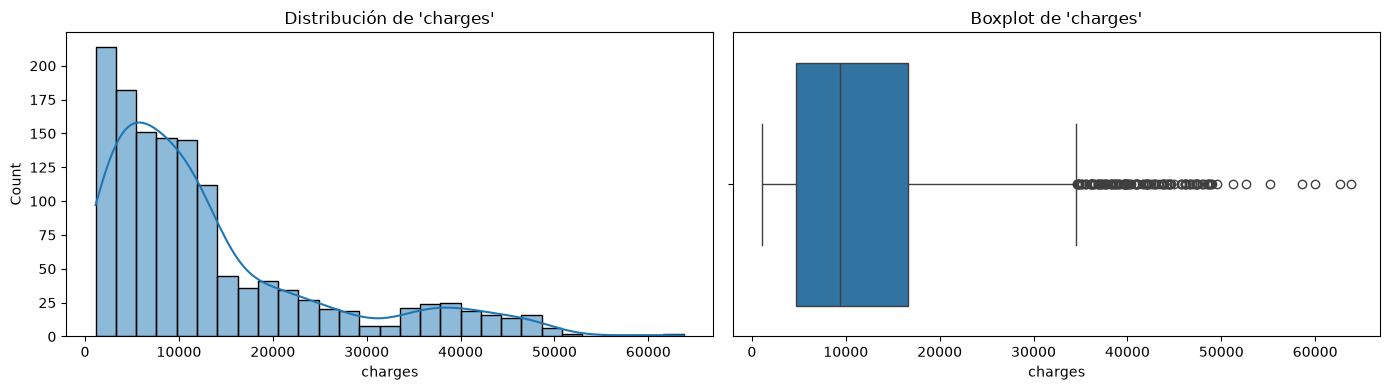

In [48]:
analizar_numerica(df, "charges")